In [1]:
import os
import pandas as pd
import shap


file_root_shapley = os.path.join(
    "..", "..", "data", "exact", "shapley_cost_value_of_myerson_star.csv"
)
file_root_grabisch = os.path.join(
    "..", "..", "data", "exact", "grabisch_of_myerson_star.csv"
)

index = [
    "P1",
    "P2",
    "P3",
    "P4",
    "P5",
    "P6",
    "P7",
    "P8",
    "P9",
    "P10",
]
shapley_only = pd.read_csv(
    file_root_shapley,
    sep=";",
    header=None,
    names=["value"]
)
shapley_only["player"] = index
psi_1 = shapley_only.set_index("player", verify_integrity=True)

r_1 = pd.read_csv(
    file_root_grabisch,
    sep=";",
    header=0
)
r_1.columns = index
r_1["player"] = index
r_1 = r_1.set_index("player", verify_integrity=True)

In [2]:
import math
from cgt_perezsechi.manipulation.norm import normalize_psi, normalize_r


n = 4
psi_1_truncated = psi_1.copy()
psi_1_truncated["value"] = psi_1_truncated["value"].astype(float).apply(lambda number: math.floor(number * 10 ** n) / 10 ** n)

r_1_truncated = r_1.astype(float).apply(lambda row: row.apply(lambda number: math.floor(number * 10 ** n) / 10 ** n))

psi_2 = normalize_psi(psi_1)
psi_2_truncated = psi_2.copy()
psi_2_truncated["value"] = psi_2_truncated["value"].astype(float).apply(lambda number: math.floor(number * 10 ** n) / 10 ** n)

r_2 = normalize_r(r_1)
r_2_truncated = r_2.astype(float).apply(lambda row: row.apply(lambda number: math.floor(number * 10 ** n) / 10 ** n))

/home/secci/Localspace/UCM/thesis/thesis-python/.venv/lib/python3.10/site-packages/cgt_perezsechi/manipulation/norm.py:8: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  max_edge_width = r.applymap(lambda x: abs(x)).max().max()
/home/secci/Localspace/UCM/thesis/thesis-python/.venv/lib/python3.10/site-packages/cgt_perezsechi/manipulation/norm.py:9: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  r = r.copy().applymap(lambda x: x / max_edge_width)


In [3]:
import networkx as nx

r1_positive = r_1.copy(deep=True)
r1_positive[r1_positive < 0] = 0

r1_negative = r_1.copy(deep=True)
r1_negative[r1_negative > 0] = 0
r1_negative = r1_negative.abs()

r1_absolute = r_1.copy(deep=True)
r1_absolute = r1_absolute.abs()

r_1s = {
    "positive": r1_positive,
    "negative": r1_negative,
    "original": r_1,
    "absolute": r1_absolute,
}

for name, r in r_1s.items():
    G_weighted = nx.from_pandas_adjacency(r, create_using=nx.DiGraph())
    weighted_clustering_coeffs = nx.clustering(G_weighted, weight='weight')

    # print(f"Weighted clustering coefficients for each node ({name}):")
    # for node, coeff in weighted_clustering_coeffs.items():
    #     print(f"{node}: {coeff:.4f}")

    print(f"\nAverage weighted clustering coefficient ({name}): {nx.average_clustering(G_weighted, weight='weight'):.4f}")


Average weighted clustering coefficient (positive): 0.0000

Average weighted clustering coefficient (negative): 0.0000

Average weighted clustering coefficient (original): 0.0000

Average weighted clustering coefficient (absolute): 0.0000


In [4]:
positive_alpha = 0.0
negative_alpha = 0.0
positive_beta = 0.0
negative_beta = 0.0

In [5]:
def filter_to_adjacency_matrix(matrix, positive_beta, negative_beta):
    def filter_edge(x):
        if x > 0 and abs(x) > positive_beta:
            return 1
        elif x < 0 and abs(x) > negative_beta:
            return 1
        else:
            return 0
    
    return matrix.copy().applymap(filter_edge)

def filter_node_list(lst, positive_alpha, negative_alpha):
    def filter_node(x):
        if positive_alpha == 0 and negative_alpha == 0:
            return True
        elif x > 0 and abs(x) > positive_alpha:
            return True
        elif x < 0 and abs(x) > negative_alpha:
            return True
        else:
            return False
    return filter(filter_node, lst)

In [6]:
A = filter_to_adjacency_matrix(r_2, positive_beta, negative_beta).to_numpy()
M = r_2.copy().to_numpy()

/tmp/ipykernel_6902/2779306892.py:10: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return matrix.copy().applymap(filter_edge)


In [ ]:
from cgt_perezsechi.modeling.cluster import (
    normalize_weighted_adjacency,
    detect_communities
)

# Normalize the adjacency matrix (r_1 contains positive and negative relations)
M_normalized = normalize_weighted_adjacency(
    r_1.to_numpy(), 
    alpha1=0.5,  # Weight for positive relations
    alpha2=0.5   # Weight for negative relations
)

# Detect communities using Louvain algorithm
columns = r_1.columns.tolist()
clusters = detect_communities(
    M_normalized,
    nodes=columns,
    resolution=1,
    seed=42          # For reproducibility
)

In [8]:
shap_cmap = shap.plots.colors.red_blue
positive_color = shap_cmap(1.0)[:3]
negative_color = shap_cmap(0.0)[:3] 

/home/secci/Localspace/UCM/thesis/thesis-python/.venv/lib/python3.10/site-packages/cgt_perezsechi/visualization/graph.py:366: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  r = r.copy().applymap(filter_edge)
/home/secci/Localspace/UCM/thesis/thesis-python/.venv/lib/python3.10/site-packages/cgt_perezsechi/visualization/graph.py:367: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  adjacency = r.copy().applymap(lambda x: 1 if x != 0 else 0)


Saving the graph to ../../results/Cap4/Fig8.jpg


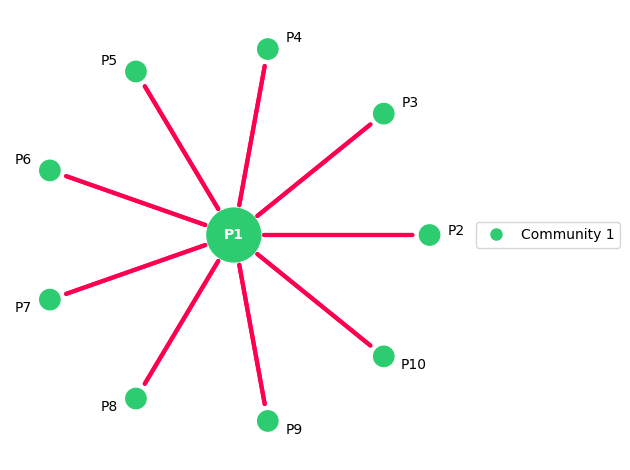

In [9]:
from math import cos, sin
from cgt_perezsechi.visualization.graph import draw_clusters

labels = [
    "P2",
    "P3",
    "P4",
    "P5",
    "P6",
    "P7",
    "P8",
    "P9",
    "P10",
]
node_pos = {
    label: (cos(i * 2 * math.pi / len(labels)), sin(i * 2 * math.pi / len(labels)))
    for i, label in zip(range(len(labels)), labels)
}
node_pos["P1"] = (0,0)

draw_clusters(
    psi=psi_2,
    r=r_2,
    clusters=clusters,
    node_pos=node_pos,
    positive_alpha=positive_alpha,
    negative_alpha=negative_alpha,
    positive_beta=positive_beta,
    negative_beta=negative_beta,
    symmetric=True,
    positive_color=positive_color,
    negative_color=negative_color,
    output_path=os.path.join('..', '..', 'results', 'Cap4', 'Fig8.jpg')
)